# Cross-Lingual Embedding Analysis

This notebook compares different multilingual embedding models:
- SONAR (facebook/SONAR_200_text_encoder_hf)
- LaBSE (sentence-transformers/LaBSE)
- LASER3 (sentence-transformers/LaBSE)

We'll evaluate them on the FLORES dataset for both:
1. Single language similarity (monolingual retrieval)
2. Cross-lingual similarity (cross-lingual retrieval)

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from functools import partial
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
from wtpsplit import SaT

from lcm_explo.m2m_100 import M2M100EncoderModel
from lcm_explo.domain.usecases.similarity import compute_xsim
# from lcm_explo.domain.usecases.encode import encode_text_sonar, split_long_text

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [3]:
sonar_model = M2M100EncoderModel.from_pretrained("cointegrated/SONAR_200_text_encoder_hf").to(device)
sonar_tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M")

labse_model = SentenceTransformer("sentence-transformers/LaBSE").to(device)

laser_model = SentenceTransformer("gowitheflow/LASER-cubed-bert-base-unsup").to(device)

splitter = SaT("sat-3l")

print("Models loaded successfully!")

Models loaded successfully!


In [38]:
def split_long_text(text: str, max_length: int = 1024) -> list[str]:
    """Split text into smaller chunks if it's too long."""
    tokens = sonar_tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    if len(tokens) <= max_length:
        return [text]

    # Use the tokenizer to split into sentences
    splits = splitter.split(text)
    return splits


def encode_text_sonar(texts: list[str]) -> np.ndarray:
    """Encode texts using SONAR model."""
    embeddings = []

    with torch.no_grad():
        for text in texts:
            # Split if needed
            chunks = split_long_text(text)
            chunk_embeddings = []

            for chunk in chunks:
                inputs = sonar_tokenizer(chunk, return_tensors="pt", padding=True, truncation=True).to(device)
                outputs = sonar_model(**inputs)
                chunk_embeddings.append(outputs.last_hidden_state.mean(dim=1).cpu().numpy())

            # Average embeddings if text was split
            embedding = np.mean(chunk_embeddings, axis=0)
            embeddings.append(embedding)

    return np.vstack(embeddings)

In [39]:
flores = load_dataset("facebook/flores", "all")

languages = [
    "eng_Latn",
    "fra_Latn",
    "deu_Latn",
    "spa_Latn",
    "cym_Latn",
    "jpn_Jpan",
    "kor_Hang",
    "ace_Arab",
    "amh_Ethi",
    "tam_Taml",
    "lao_Laoo",
    "shn_Mymr",
]
split = "devtest"

raw_data = flores[split][:]
data = {}
for lang in languages:
    data[lang] = raw_data[f"sentence_{lang}"][:400]

print(f"Loaded {len(languages)} languages with {len(data[languages[0]])} sentences each")

Using the latest cached version of the module from /Users/yann.hallouard/.cache/huggingface/modules/datasets_modules/datasets/facebook--flores/2a1174c8c4991ca09a9cb5b9a367cb2e049b073852cb4097456164d4612391ef (last modified on Thu Apr  3 14:58:58 2025) since it couldn't be found locally at facebook/flores, or remotely on the Hugging Face Hub.


Loaded 12 languages with 400 sentences each


In [41]:
def evaluate_model(model_name: str, encoder_fn, data: dict[str, list[str]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    embeddings = {}
    for lang in tqdm(data.keys(), desc="Computing embeddings"):
        embeddings[lang] = encoder_fn(data[lang])

    mono_results = []
    for lang in tqdm(data.keys(), desc="Monolingual evaluation"):
        error_rate = compute_xsim(embeddings[lang], embeddings[lang])
        mono_results.append({"Language": lang, "Error Rate": error_rate})

    cross_results = []
    for src_lang in tqdm(data.keys(), desc="Cross-lingual evaluation"):
        for tgt_lang in data:
            if src_lang != tgt_lang:
                error_rate = compute_xsim(embeddings[src_lang], embeddings[tgt_lang])
                cross_results.append({"Source": src_lang, "Target": tgt_lang, "Error Rate": error_rate})

    return pd.DataFrame(mono_results), pd.DataFrame(cross_results)

In [42]:
sonar_mono, sonar_cross = evaluate_model("SONAR", encode_text_sonar, data)

labse_mono, labse_cross = evaluate_model("LaBSE", lambda texts: labse_model.encode(texts, convert_to_numpy=True), data)

laser_mono, laser_cross = evaluate_model("LASER3", lambda texts: laser_model.encode(texts, convert_to_numpy=True), data)

Computing embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Monolingual evaluation:   0%|          | 0/12 [00:00<?, ?it/s]

Cross-lingual evaluation:   0%|          | 0/12 [00:00<?, ?it/s]

Computing embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Monolingual evaluation:   0%|          | 0/12 [00:00<?, ?it/s]

Cross-lingual evaluation:   0%|          | 0/12 [00:00<?, ?it/s]

Computing embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Monolingual evaluation:   0%|          | 0/12 [00:00<?, ?it/s]

Cross-lingual evaluation:   0%|          | 0/12 [00:00<?, ?it/s]

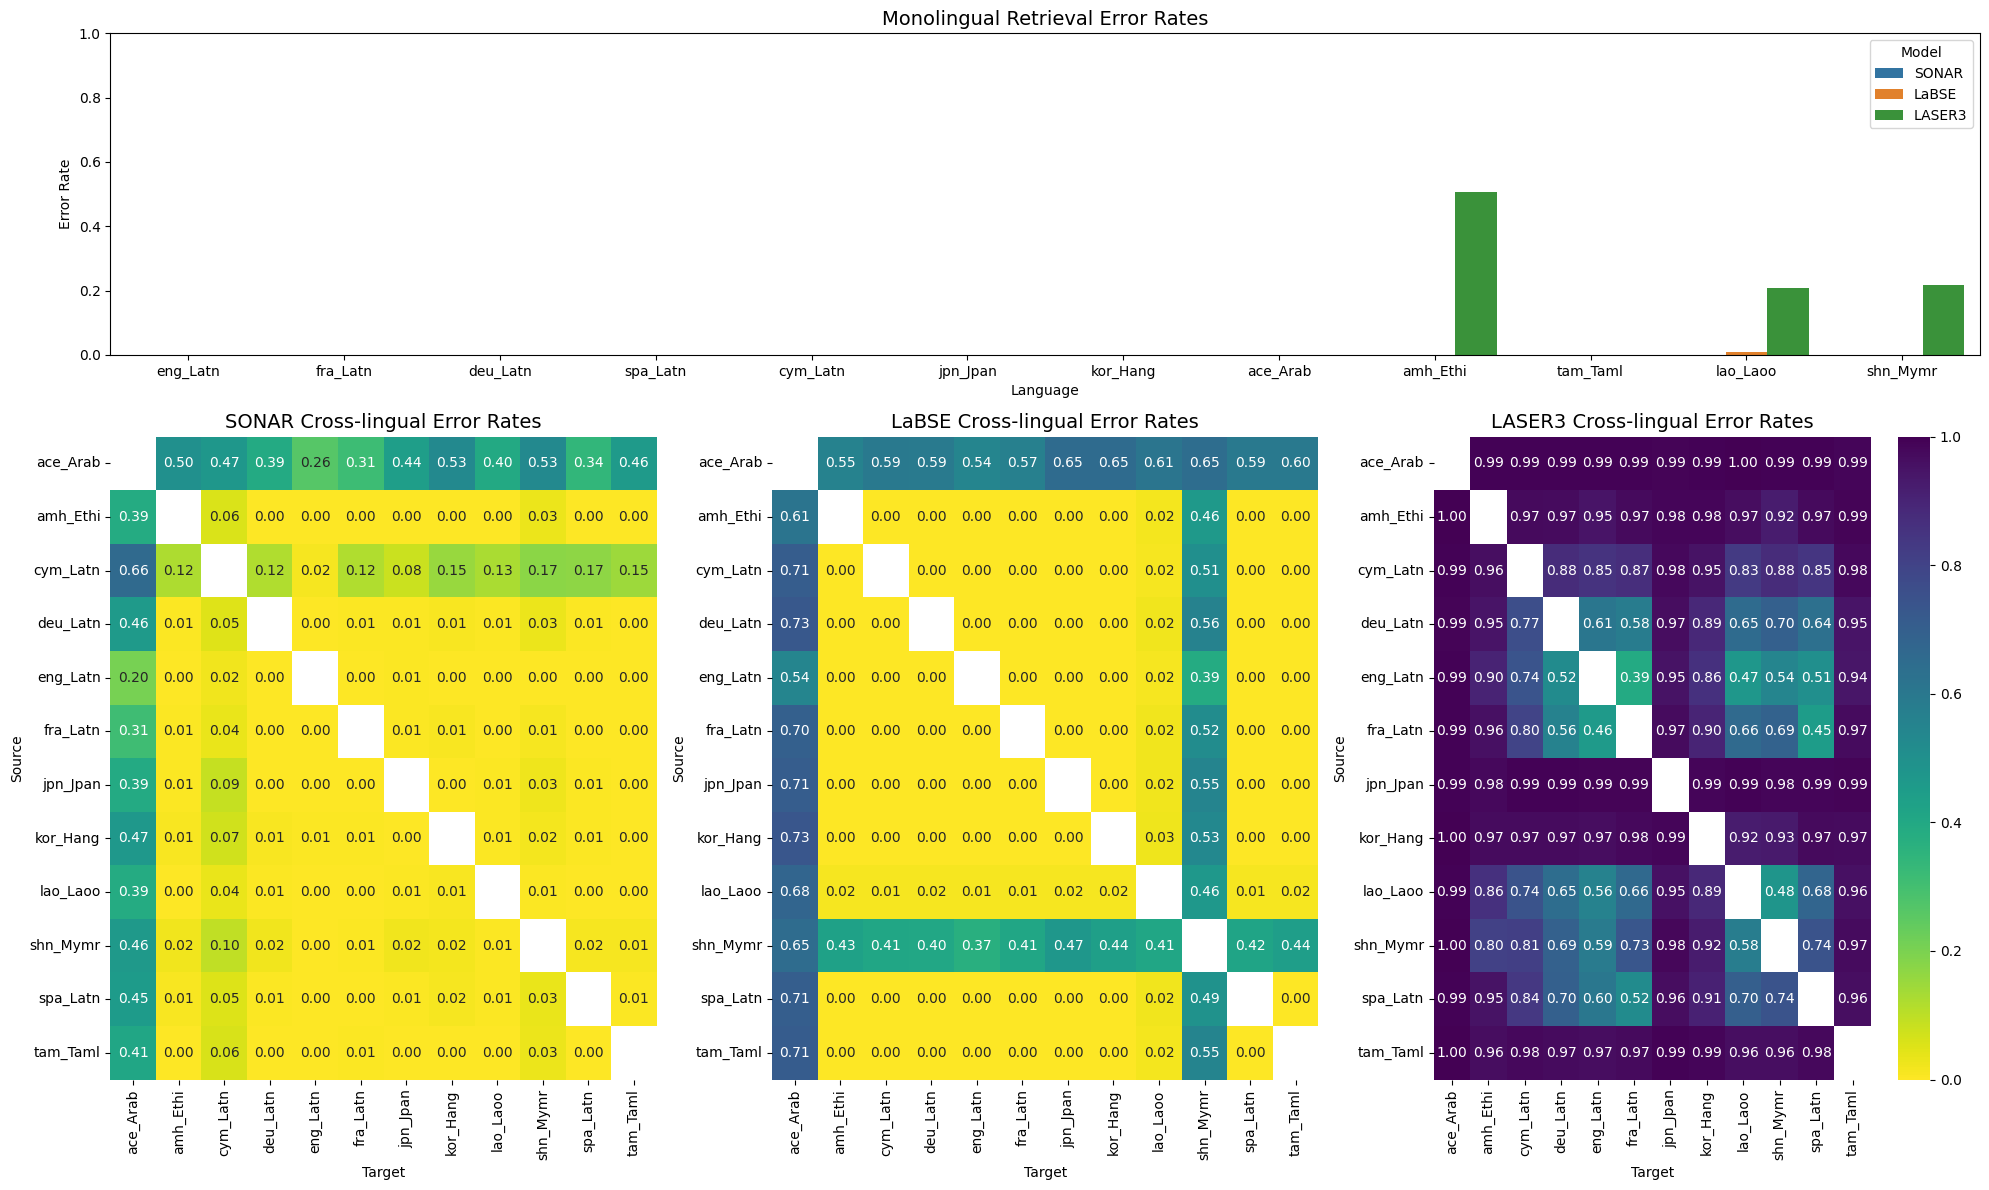

In [43]:
import matplotlib.gridspec as gridspec
import pandas as pd


def plot_cross_lingual_heatmaps(
    mono_results: list[pd.DataFrame], cross_results: list[pd.DataFrame], model_names: list[str]
):
    """Plot comparison of model performances with heatmaps for cross-lingual results."""
    fig = plt.figure(figsize=(20, 12))

    # Create a grid of subplots (2 rows: 1st for monolingual, 2nd for 3 heatmaps)
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 2], figure=fig)

    # Monolingual plot
    ax1 = fig.add_subplot(gs[0, :])
    for df, name in zip(mono_results, model_names):
        df["Model"] = name
    mono_combined = pd.concat(mono_results)

    sns.barplot(data=mono_combined, x="Language", y="Error Rate", hue="Model", ax=ax1)
    ax1.set_title("Monolingual Retrieval Error Rates", fontsize=14)
    ax1.set_ylim(0, 1)

    # Cross-lingual heatmaps
    for i, (cross_df, name) in enumerate(zip(cross_results, model_names)):
        ax = fig.add_subplot(gs[1, i])

        # Create a pivot table with Source as rows and Target as columns
        heatmap_data = cross_df.pivot_table(values="Error Rate", index="Source", columns="Target", aggfunc="mean")

        # Create the heatmap
        sns.heatmap(
            heatmap_data,
            cmap="viridis_r",  # Reversed viridis (lower values are yellow)
            vmin=0,
            vmax=1,
            annot=True,
            fmt=".2f",
            cbar=i == 2,  # Only show colorbar for the last heatmap
            ax=ax,
        )

        ax.set_title(f"{name} Cross-lingual Error Rates", fontsize=14)

    plt.tight_layout()
    return fig


fig = plot_cross_lingual_heatmaps(
    [sonar_mono, labse_mono, laser_mono], [sonar_cross, labse_cross, laser_cross], ["SONAR", "LaBSE", "LASER3"]
)

In [44]:
# Print detailed statistics
print("\nMonolingual Retrieval Error Rates (Mean ± Std):")
for name, df in zip(["SONAR", "LaBSE", "LASER3"], [sonar_mono, labse_mono, laser_mono]):
    mean = df["Error Rate"].mean()
    std = df["Error Rate"].std()
    print(f"{name}: {mean:.3f} ± {std:.3f}")

print("\nCross-lingual Retrieval Error Rates (Mean ± Std):")
for name, df in zip(["SONAR", "LaBSE", "LASER3"], [sonar_cross, labse_cross, laser_cross]):
    mean = df["Error Rate"].mean()
    std = df["Error Rate"].std()
    print(f"{name}: {mean:.3f} ± {std:.3f}")


Monolingual Retrieval Error Rates (Mean ± Std):
SONAR: 0.000 ± 0.000
LaBSE: 0.001 ± 0.003
LASER3: 0.077 ± 0.158

Cross-lingual Retrieval Error Rates (Mean ± Std):
SONAR: 0.088 ± 0.158
LaBSE: 0.179 ± 0.265
LASER3: 0.871 ± 0.162
